# 리포트 8-2 — 마이크로도플러: 세 엔진과 거리

> **8 권은 다섯 편이다** — [08_1 시나리오](08_1_scene.ipynb) · [08_2 세 엔진과 거리](08_2_engines.ipynb) · [08_3 무늬를 정하는 것](08_3_pattern.ipynb) · [08_4 무엇을 잴 수 있나](08_4_sampling.ipynb) · [08_5 바이스태틱](08_5_bistatic.ipynb)

> **같은 장면을 세 가지로 계산하면 무엇이 갈리나.** 대조군이 없으면 우리 맵이 틀렸는지 알 방법이 없다.

장면은 [08_1](08_1_scene.ipynb) 이 세웠다. 이 편은 **계산 엔진**만 다룬다.

⭐ 본문 숫자는 계산 결과 JSON(원장)에서 주입된다 — 원장이 다시 계산되면 `python src/make_report08_microdoppler.py` 한 번으로 본문 숫자가 따라 바뀐다. 원장이 없는 자리는 «원장 없음» 이라고 적고 그 숫자를 비율·헤드라인에서 뺀다.




## 세 엔진이 각각 무엇을 하나

| 엔진 | 무엇을 쏘나 | 무엇을 세나 | 무엇이 빠지나 |
|---|---|---|---|
| **Sionna PathSolver** | TX 에서 광선을 뿌린다 | 표적을 맞고 돌아온 **경로**의 진폭·지연으로 h = Σ a_p·e^(−j2πf_cτ_p) | 경로가 열 가닥 남짓이라 재료가 성기다. 프롭을 맞은 **정반사** 경로는 이 격자에서 **0 칸**(아래) |
| **Ours (SBR+PO, 기본)** | 표적에 **앵커한** λ/12(= 7.1 mm) 격자로 평면파 조명 — 자세당 광선 15,376 발(얼린 판 한 변 124 칸 — 아래 **절 «광선 격자를 어디에 매나»**) | 광선이 **처음 맞은 지점만** 면적분 — E = Σ&#124;Γ(θ)&#124;·e^(j2k p·û)·d² (입사 코사인은 가중이 아니라 **문지기**다: n̂·û>0 인 점만 든다. 광선을 û 로 쏘므로 셀의 투영면적이 d² 와 상쇄된다) | 가려진 면이 자동으로 빠진다 (가림이 공짜) |
| **Ours, nothing blocked (control)** | 광선을 안 쓴다 | 점구름의 **모든 면**을 더한다 — E = Σ(n̂·û>0) &#124;Γ&#124;·(n̂·û)·ΔA·e^(j2k p·û) (여기서는 코사인이 **가중**이다) | ⚠**아무것도 안 빠진다** — 남의 뒤에 숨은 면도 셈에 든다 |

⭐ 셋째 열은 **물리적으로 불가능한 상태**다. 오직 «가림이 얼마나 바꾸나» 를 재는 대조군으로만 쓴다. ⚠«드론 일부만 그린 것» 이 아니다 — 동체도 프로펠러도 다 들어간다.

⚠ **둘째와 셋째는 가림 말고 이산화 방식도 다르다**(광선 격자 ↔ 점구름). 그래서 둘의 차이가 «가림만» 의 값은 아니다. 가림만 떼어낸 깨끗한 축은 `report15b` 의 F(동체 Γ=0 — 막되 산란 안 함) ↔ G(동체 면만 제거, 정점은 남겨 광선 격자 동일) 이고, 이 편의 자세(배 쪽)에서 그 실측은 레벨 +1.31 dB · 변조 깊이 -4.79 dB 다 — 같은 값을 [08_3](08_3_pattern.ipynb) 이 그림과 함께 낸다.


## 세 엔진을 같은 격자에, 거리 3 / 8 / 15 m (거리축은 Sionna 열만)

**시나리오** — 같은 기체·자세·주파수·PRF·로터별 회전수로 세 엔진을 돌리고 거기에 거리축을 얹었다. 4,096 표본 @ PRF 19700 Hz = 26 블레이드 주기(= 208 ms), 로터 산포 ±0.22 %(PX4 **SITL**(소프트웨어 시뮬) 중간값 — ⚠실기 계측이 아니다). 기하는 **진짜 모노스태틱**(TX=RX, 기선 0)이다.

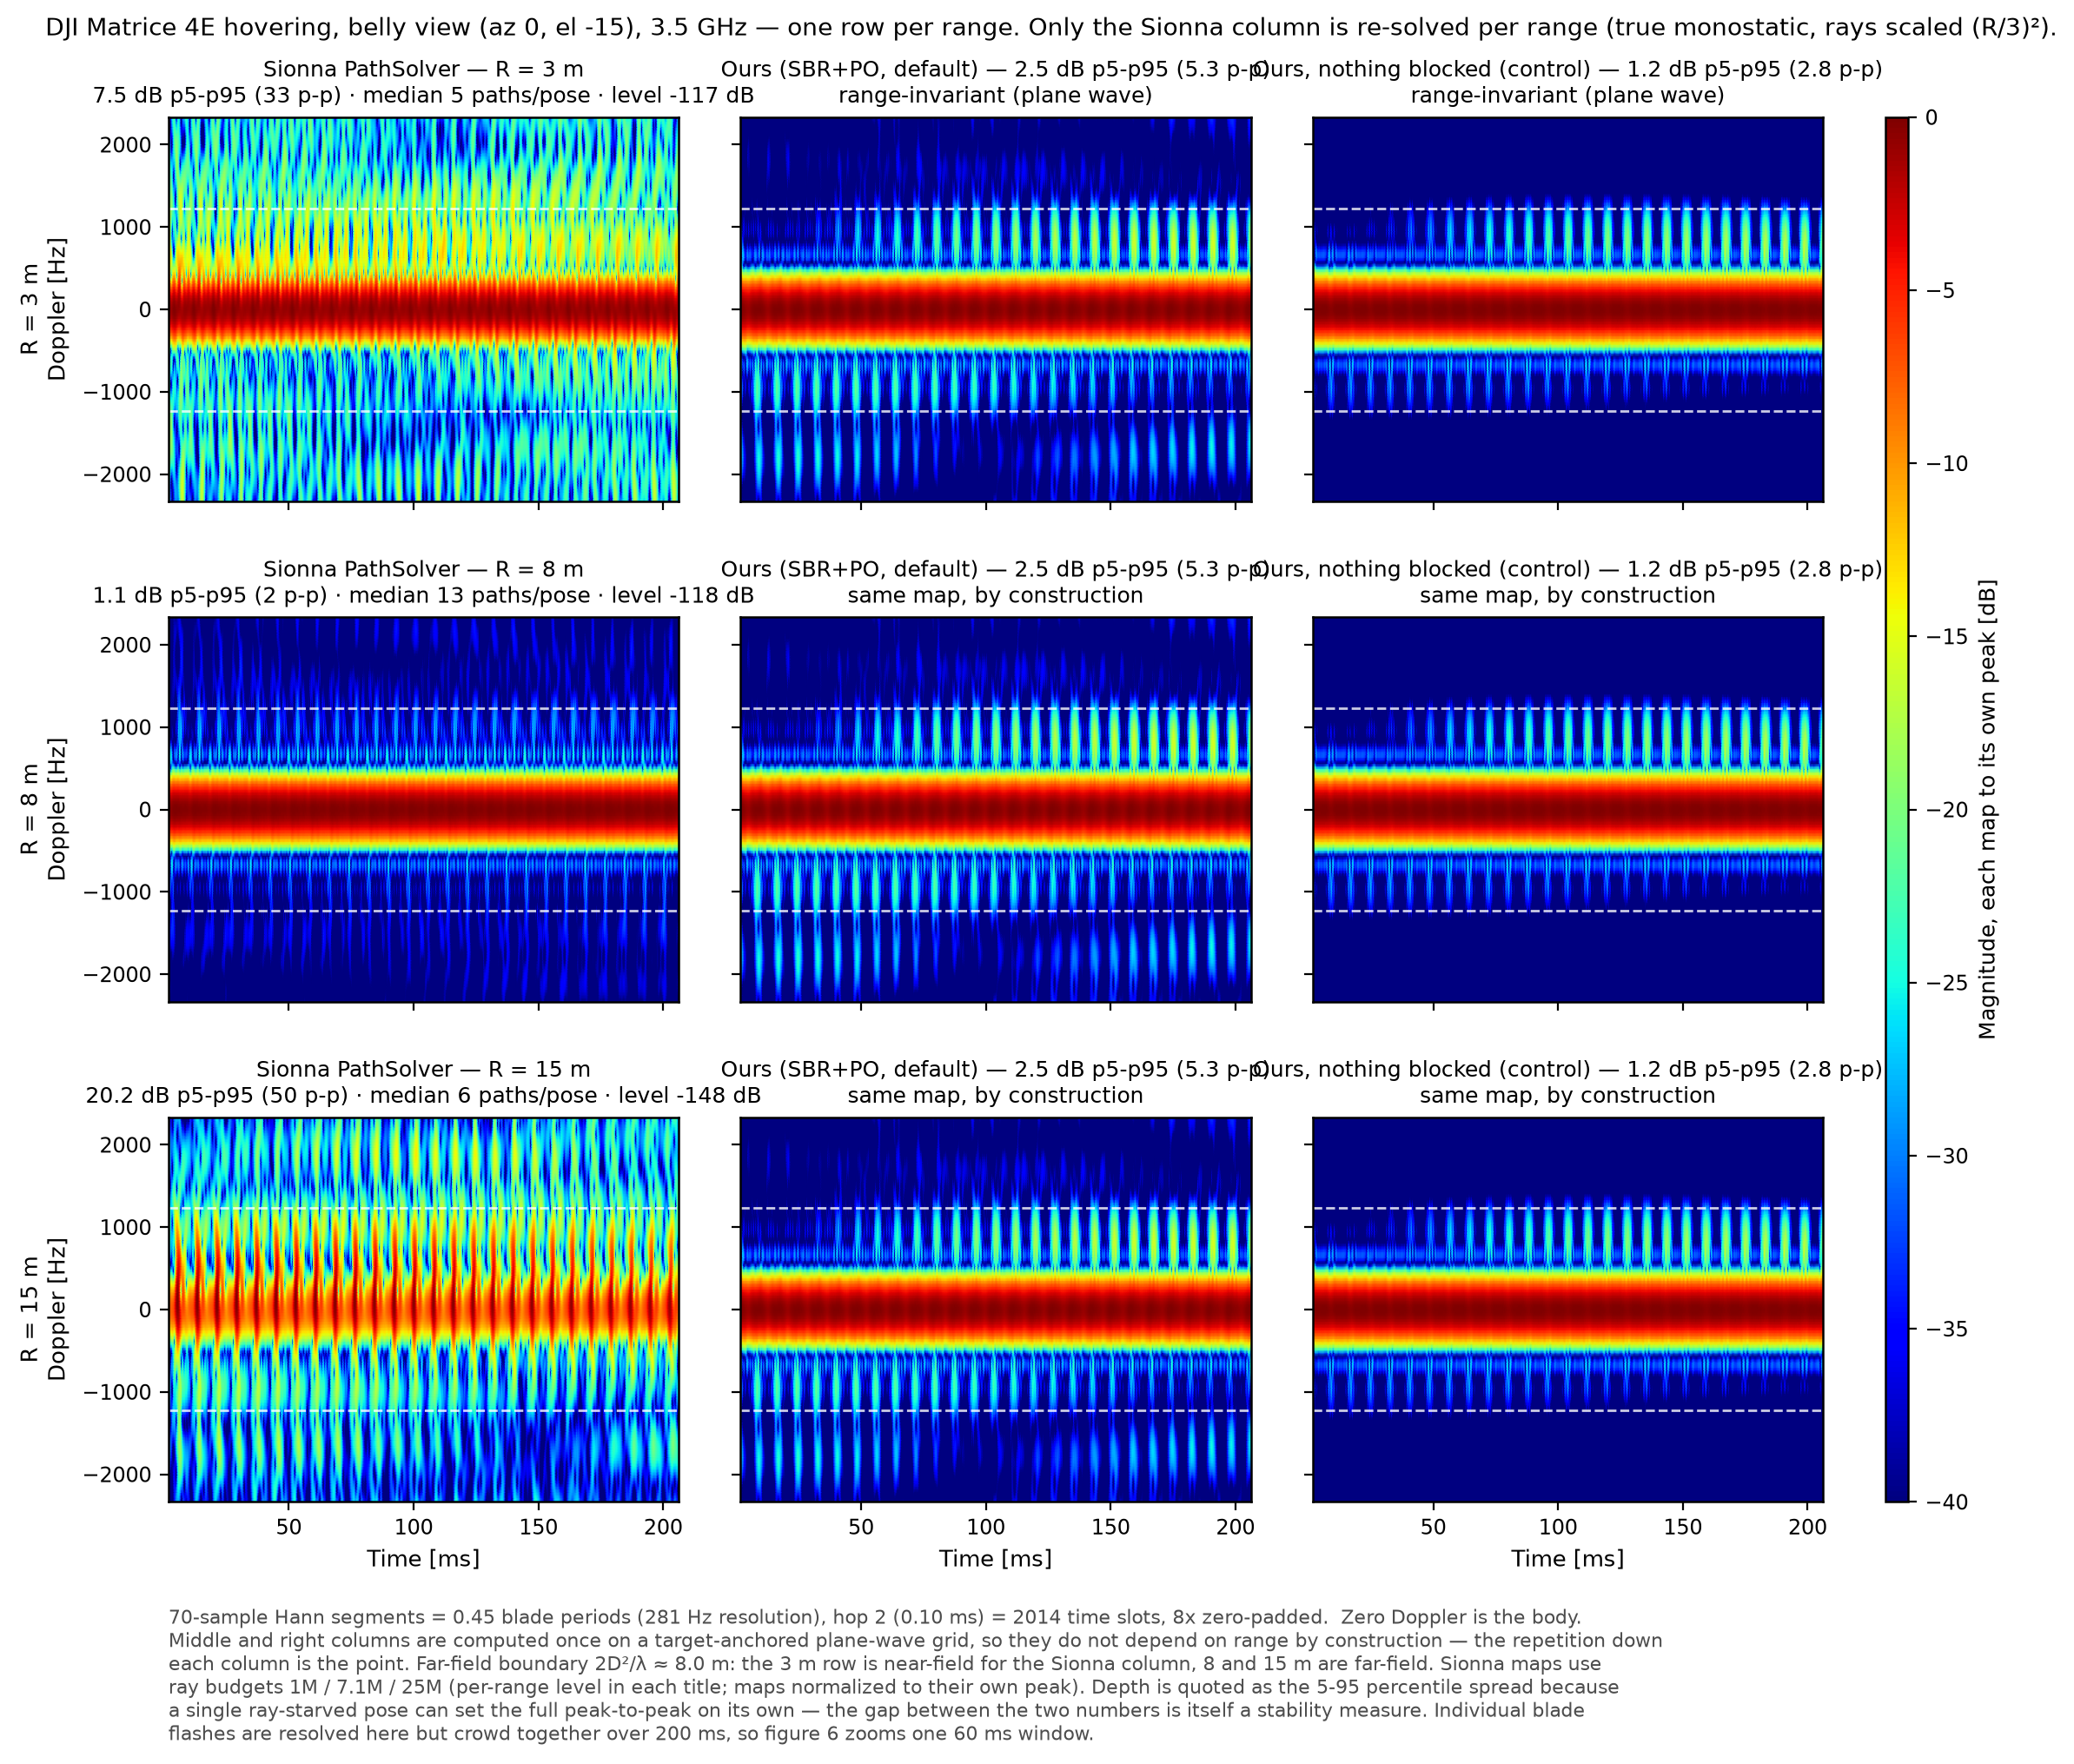

⭐ **왼쪽 열만 거리마다 다시 풀었다.** 가운데·오른쪽 열은 표적 앵커 평면파 조명이라 **거리라는 변수 자체가 없고**, 그래서 세 줄에서 같은 맵이 반복된다 — 그 반복이 이 그림의 절반이다.

⚠ **그 배선을 원장이 스스로 적는다** — «그림3(report07_three_engines) 격자·회전수 재사용 — sbr·po 열은 거리 무관이라 그 원장을 그대로 쓴다»(`outputs/report07_three_engine_ranges.json:_meta.grid_note_ko`). 즉 세 거리를 다시 푼 팔은 **Sionna 하나**이고, 우리 두 팔의 «거리 무관» 은 이 그림이 잰 것이 아니라 이 파이프라인의 전제다. 그 전제를 따로 잰 원장은 `outputs/deck_ours_by_range.json`(구면파 위상으로 3 / 15 / 40 m 를 다시 계산) 이고, [08_4](08_4_sampling.ipynb) §1 이 그것을 읽는다.

⚠ **8 m 가 원거리장 경계(8.3 m · D = 수평 최대치수) 곁이라는 사실은 이 그림에서 아무 역할도 하지 않는다.** Sionna PathSolver 에는 근/원거리장 구분이 아예 없고(경로의 지연이 2R/c 를 표적 반지름만큼만 감싼다), 8 m 를 특별하게 만드는 것은 기하가 아니라 **난수 추첨**이다 — 아래 참조.

**깊이는 두 자로 잰다** — p-p(max−min)는 자세 하나가 혼자 끌 수 있어서, 양 끝 5 %를 버린 **p5~p95**(95 백분위 − 5 백분위) 를 함께 낸다. 둘의 **비**가 그 팔의 안정성이다. 표는 `outputs/report07_depth_robust.json` 을 읽는다.

| 엔진 | p-p | p5~p95 | 비 | 무늬 |
|---|---|---|---|---|
| Sionna PathSolver | 32.6 dB | 7.5 dB | 4.3× | 얼룩이 대역을 채우고 날개끝 밖에도 남는다 — 전체 전력의 5.06 % 가 f_tip 밖 |
| Ours (SBR+PO, 기본) | 5.3 dB | 2.5 dB | 2.2× | 빗살이 또렷하다 — 0.18 % 가 f_tip 밖(⚠대조군보다는 여전히 35 dB 위다) |
| Ours, nothing blocked (control) | 2.8 dB | 1.2 dB | 2.3× | 빗살이 가장 좁고 날개끝에서 절벽처럼 잘린다 — 0.00007 % |

⚠ **이 표의 깊이를 물리량으로 인용하지 마라.** 같은 Sionna 팔을 거리만 바꿔 재면 p-p 가 32.6 / 2.5 / 50.1 dB 로 요동친다(3 / 8 / 15 m). 그 요동은 물리가 아니라 **광선 표본화**다 — 강건한 p5~p95 로 보면 7.5 / 1.1 / 20.2 dB 다. ⚠ 그중 **8 m 의 작은 값은 «변조가 얕다» 가 아니라 «플래시가 없다» 는 뜻**이다 — 자세에 안 변하는 정적 받침대가 프롭 변조보다 27.6 dB 높아 깊이가 눌린 것이다(아래 «추첨 한 장» 참조). ⚠ 그리고 폭을 정하는 것은 이상치 **하나가 아니다** — 최솟값 자세를 빼고 다시 재도 3 m 는 27.1 dB, 15 m 는 45.1 dB 가 남는다. **꼬리가 두꺼운 것**이다.

⭐ 셋 다 **(a) 0 도플러 동체 선 · (b) 통과율 간격 능선 · (c) 날개끝 근처 감쇠**를 낸다 — 구조가 일치한다. 날개끝 안 스펙트럼 코사인은 Sionna↔SBR+PO **0.745** · Sionna↔대조군 **0.760** · 기본↔대조 **0.955** 다.

⭐ **이 코사인이 무엇인가** — 두 팔의 슬로타임 스펙트럼을 |f| ≤ f_tip 안에서 **크기만** 취해 정규화한 뒤 내적한 값이다(위상 원점 무관 · 1 이면 같은 모양).

⭐ **이 실행의 대소** — 우리 두 팔끼리 0.955 > Sionna↔대조군 0.760 > Sionna↔우리 기본팔 0.745. 우리 두 팔이 서로 가장 닮았고, Sionna 는 그 둘에서 비슷한 거리만큼 떨어져 있다 — 광선을 쓰는 두 구현(Sionna·우리 SBR)이 서로 닮은 것이 아니라, **가림을 빼면 우리 두 팔이 같은 물리를 낸다**는 쪽이다.

⚠ **세 자리를 절대 척도로 인용하지 마라 — 격자 간격에 딸려 움직인다.** 같은 두 팔을 간격만 바꿔 재면 기본↔대조가 λ/8 0.955 · λ/12 0.953 · λ/16 0.968 · λ/24 0.976 · λ/32 0.983 로 옮겨 다닌다(`outputs/sbr_grid_convergence.json` · 얼린 팔). 같은 사다리에서 자세마다 격자를 다시 정의하는 팔은 0.426~0.514 에 눌려 있고, 간격을 촘촘히 해도 거기서 안 올라온다 — 그 팔의 한계는 광선 밀도가 아니었다. 즉 이 수가 말하는 것은 **이 실행에서의 순서**까지다.

⭐ **이 편의 맵은 얼린 광선 격자로 풀었다** — 판 한 장을 모든 자세가 함께 쓴다. 그것이 무엇이고 이 편의 숫자를 얼마나 옮겼는지는 아래 **절 «광선 격자를 어디에 매나»** 가 낸다.

| 세 팔의 대역밖 (모노 원장) | **전체 전력** 중 f_tip 밖 몫 | 날개끝 밖 바닥 |
|---|---|---|
| Ours, nothing blocked (control) | 0.00007 % | -127.2 dB |
| Sionna PathSolver | 5.06 % | -47.6 dB |
| Ours (SBR+PO, 기본) | 0.18 % | -62.2 dB |

⚠ **이 칸의 정의** — 평활 없는 주기도에서 |f| > f_tip 의 전력을 **전 대역 전력**으로 나눈 몫이다(분모를 열 제목에 박아 두었다). «날개끝 밖 바닥» 은 같은 주기도의 f_tip 밖 평균을 봉우리 대비로 적은 값이다.

⚠ **Sionna PathSolver 행과 견줄 수 있는 것은 이 표의 두 칸뿐이다.** 그 팔이 내는 양은 수신 전력장이고 우리 두 팔은 산란 진폭[m²]이라, 원장이 그 행에 `units_comparable_to_po = false` 를 달고 **절대 전력 순위에서 뺀다**(`outputs/outofband_power.json:three_engines_ranking.new_P_out_absolute.excluded` — 절대 순위는 Ours (SBR+PO, 기본) 대 Ours, nothing blocked (control) 둘로만 매긴다). 표의 두 칸은 각 팔이 **자기 전체 전력 · 자기 봉우리**로 정규화한 무차원 값이라 나란히 읽는다. 절대 dB 는 팔 안에서만 쓴다.

⭐ **분모를 밝히지 않고는 대소를 쓰지 않는다.** 전체 전력 대비로는 SBR 이 Sionna 보다 14.5 dB 아래이고, 대역비(f_tip 밖 / 블레이드 대역)로 재면 Sionna 77.1 % 대 SBR 26.2 % 로 **같은 순서**다(4.7 dB 차). 두 잣대가 갈리지 않으므로 이 표의 대소는 정규화 선택에 안 걸린다 — 그래도 헤드라인은 분모를 이름에 박은 `frac_of_total` 로만 쓴다.

| 거리 | 광선 수 | 자세당 경로(중앙값) | 경로 0 자세 | 평균 레벨 |
|---|---|---|---|---|
| 3 m | 1.0M | 5 | 0.0% | -117.4 dB |
| 8 m | 7.1M | 13 | 0.0% | -118.0 dB |
| 15 m | 25.0M | 6 | 0.0% | -148.3 dB |

⚠⚠ **이 표의 경로 수와 레벨은 물리량이 아니라 «추첨 한 장» 이다.** Sionna 는 확산 경로를 몬테카를로로 **발견**하는데, 이 스윕은 자세 4,096 개를 전부 같은 시드로 풀었다. 드론에서 움직이는 것은 로터뿐이라 동체·랜딩기어의 경로 집합이 전 자세에서 **비트 단위로 동일**하고(정적 성분의 유일값이 1 개), 그래서 208 ms 기록 전체가 추첨 한 번을 받침대로 깔고 있다. 자세를 4,096 개 평균해도 그 추첨은 평균되지 않는다.

⭐ 기하·자세·광선 수를 **하나도 안 바꾸고 시드만** 바꾼 실측(8 m · 자세 512 개): 레벨이 -118.0 / -136.0 / -121.4 dB 로 **18 dB** 흔들리고, 최강선이 3.018 / 1.006 / 0.999 ·f_flash 로 바뀐다. 즉 «8 m 만 3 배 조화» 도 «레벨이 안 떨어진다» 도 **거리의 성질이 아니라 이 시드의 성질**이다. 세 거리를 모두 같은 광선 수(25M)로 다시 풀면 최강선이 0.976 / 0.998 / 0.991 ·f_flash 로 셋 다 기본파에 꽂힌다.

⚠ 그리고 이 팔의 절대 레벨은 **광선 수에 수렴하지 않는다**. 우리가 재는 것은 h = Σ a_p e^(−j2πf_c τ_p) 인데, Sionna 는 확산 경로 진폭을 **전력 합**이 광선 수와 무관하도록 정규화한다. 그것을 코히어런트로 더하면 광선을 늘릴수록 값이 커진다 — √spp 에 대한 실측 기울기가 3 m 에서 +0.52~+0.69 다(같은 잣대로 8 m 는 -0.01~+0.09 라, 부풀림의 크기 자체가 자세·거리에 딸린다). 반면 Σ&#124;a_p&#124;² 의 기울기는 -0.04~-0.01 로 평평하다. 거리마다 다른 광선 수를 준 이 표는 거리마다 다른 부풀림을 섞고 있다.

⇒ **이 표에서 인용해도 되는 것은 «빈 자세 0 %» 뿐이다**(그것은 시드에 둔감하다). 원장: `outputs/probe_8m_anomaly.json`.


## 광선 격자를 어디에 매나

> **자를 프레임마다 다시 놓으면, 자가 움직인 것이 표적이 움직인 것으로 기록된다.**

우리 커널은 표적 앞에 **평면 자**를 세우고 그 격자점마다 광선을 쏜다. 자를 정하는 것은 중심 ctr · 반경 Rout · 한 변의 칸수 n 셋이다. 그 셋을 **자세마다 표적 경계상자에서 다시 뽑으면** 프로펠러가 돌 때마다 상자가 숨을 쉬므로 자도 같이 움직인다. 마이크로도플러는 **프레임 사이 위상차**로 재는 양이라, 그 움직임이 표적의 운동으로 기록된다.

실측은 **검증판**에서 났다(계약 게이트 `outputs/verify_frozen_grid.json` · 로터 한 바퀴를 16 등분한 봉투 · 같은 기체·자세 · 자세 64 개 · λ/12): 자세마다 다시 뽑는 자는 한 변이 101~129 칸을 오가며 61 번 튀고, 위상 원점이 시선 방향으로 9.8 mm · 반경이 98 mm 돌아다닌다. 얼린 판은 한 변 124 칸으로 **0 번** 바뀐다.

⭐ **이 편이 쓴 판은 생산판이다** — 로터 한 바퀴를 24 등분해 그 메쉬들의 합집합 경계상자로 한 번 만든 판이다: 한 변 124 칸 · 간격 7.138 mm · 반경 44.2 cm. 4,096 자세가 전부 이 한 장을 쓴다(`outputs/report07_three_engines.json:engines.sbr.grid_ref`).

⚠ **두 판은 봉투가 다르다** — 검증판은 한 바퀴 16 등분, 생산판은 24 등분이다. 한 변 칸수 124 과 간격 7.138 mm 는 두 판이 같고 반경만 0.15 mm 차이라, 위 실측의 결론이 이 판에도 그대로 선다.

**결정적 검사는 가산성이다.** 서로 가리지 않는 로터의 PO 면적분은 E(φ₁..φ₄) = E₀ + Σ ΔE_j(φ_j) 로 정확히 쪼개진다 — 로터를 하나씩 돌린 변화량의 합이 넷을 함께 돌린 장과 같아야 한다. 이 잣대에는 창도 평활도 분모도 안 들어간다.

| 격자 | 가산성 잔차 (중앙값) | 읽는 법 |
|---|---|---|
| 얼린 판 한 장 | 2.3e-15 | 기계정밀도 — 정리가 그대로 성립한다 |
| 자세마다 다시 정의 | 0.167 | O(1) — 물리적으로 결합할 수 없는 로터 사이에 결합이 생긴다 |

그 가짜 결합이 그대로 변조로 실린다 — 이 자세에서 +26.7 dB 다(변조 RMS 5.00e-03 ↔ 얼린 판 2.31e-04). 기전과 다른 기체·자세의 같은 검사는 [리포트 5 «우리 커널 — 무엇이고, 무엇이 아닌가»](05_kernel.ipynb) 가 낸다 — 여기서는 **이 편의 자세**에서 그것이 성립한다는 것만 확인한다.

### 이 편의 숫자가 얼마나 옮겼나

옛 판(자세마다 다시 정의)과 새 판(얼림)을 **같은 잣대**로 나란히 잰 원장이 `outputs/freeze_before_after.json` 이다. 옛 열은 `outputs/prefreeze/` 에 사본으로 남아 있다 — 지우지 않았다.

| 잣대 | 옛 판 | 얼린 판 | 차 |
|---|---|---|---|
| 평균 레벨 20·log₁₀(mean&#124;E&#124;) | -50.34 dB | -51.55 dB | -1.20 dB |
| 변조 깊이 std&#124;E&#124;/mean&#124;E&#124; | 0.127 | 0.085 | ×0.67 |
| 변조 깊이 p-p | 7.9 dB | 5.3 dB | -2.5 dB |
| 대역밖 절대 전력 P_out (&#124;f&#124; > f_tip) | -65.9 dB | -79.0 dB | **-13.1 dB** |

⭐ **레벨은 1.2 dB 움직이는 데 그쳤는데 날개끝 밖 바닥은 13.1 dB 내려간다.** 얼리기는 신호를 키우거나 줄이는 조작이 아니라 **슬로타임 변조를 바로잡는** 조작이다. 내려간 만큼이 표적의 운동이 아니라 자의 흔들림이었다.

⚠ **같은 신호의 미세 수정이 아니다.** 옛 열과 새 열의 진폭 상관이 0.464(복소 코히런스 0.483)다 — **다른 시계열**이다. 그래서 옛 판으로 그린 그림과 새 판의 숫자를 섞어 실으면 안 된다.

같은 잣대를 이 라운드에서 다시 낸 **27 열 전부**에 먹이면(1 + 24 + 2 = 세 엔진 원장의 **sbr 열 하나** · report15b 여섯 자세 × 네 SBR 팔 · 호버 두 프리셋 — 얼리기가 닿는 것은 광선 격자를 쓰는 SBR 계열뿐이다): 레벨 차 중앙값 -0.12 dB(-2.51 ~ +0.82) · 진폭 상관 중앙값 0.411 · 변조 깊이 후/전 비 중앙값 ×0.67 · 대역밖 절대 전력 **27/27 열에서 감소**(중앙값 -10.9 dB · 최대 -22.1 dB).

⚠ 변조 깊이는 **항상 얕아지지 않는다** — 후/전 비의 범위가 ×0.27 ~ ×1.38 다. 격자 흔들림이 실제 변조를 **가리고 있던** 열도 있다는 뜻이라, «얼리면 변조가 준다» 고 쓰면 틀린다. 한 방향으로 움직인 것은 대역밖 전력뿐이다.

### 이 판을 믿을 근거 두 가지

**① 판의 위치에 둔하다.** 같은 «얼림» 을 다른 봉투로 잡은 판(`E_froz_div12` — 자세 4,096 개 전부의 합집합)과 견주면 진폭 상관 0.993 · 레벨 차 -0.006 dB 다. 얼림↔안얼림이 0.464 인 것과 나란히 놓으면, 차이를 만든 것은 판의 **위치**가 아니라 판이 **움직였다는 사실**이다.

**② 스위치를 끄면 옛 원장이 그대로 선다.** 재계산기에서 얼리기를 끄고(`SIONNA2_FREEZE_GRID=0`) 자세 12 개를 다시 풀면 6/6 열이 옛 원장과 **비트 동일**하다. 자세 격자·PRF·로터 회전수를 하나도 안 건드렸다는 증거이고, 그래서 위 표의 «전 ↔ 후» 가 격자 하나만의 차이가 된다. 커널 자체의 기본값(`grid_ref=None`)도 배선 전과 36/36 비트 동일이다.

⭐ **격자 사다리의 예측과도 맞는다 — 잣대는 우리 두 팔끼리다(Ours (SBR+PO, 기본) ↔ Ours, nothing blocked (control)).** 사다리는 얼리면 그 코사인이 0.440 → 0.953 로 오른다고 예측했고(`outputs/sbr_grid_convergence.json:in_band_fidelity` · λ/12 칸), 이 편의 생산 원장을 얼린 판으로 다시 풀어 재면 **0.955** 다 — 독립 구현의 예측을 생산 경로가 재현했다.

⚠ **PathSolver 를 잣대로 두면 방향이 반대다.** 같은 사다리에서 SBR↔Sionna PathSolver 코사인은 λ/12 칸에서 0.727 → 0.662 로, 사다리 5 칸 전부에서 0.721~0.743 → 0.603~0.695 로 **내려간다**. 얼리기는 우리 두 팔을 서로 닮게 하고 스톡 팔과는 덜 닮게 한다. 판정을 우리 두 팔끼리로 세우는 이유는 둘이 같은 물리(가림만 다른 면적분)를 풀기 때문이고, 스톡 팔은 재료가 다르다 — 순수 PO 는 점구름 적분이라 광선 격자 밖에 있고, PathSolver 는 경로가 성기다(자세당 중앙값 5 가닥). 그러므로 이 절의 심판은 **우리 두 팔끼리**다.

### 대가

| 대가 | 크기 | 무엇을 뜻하나 |
|---|---|---|
| 광선 수 | ×1.108 (+10.8 %) | 전 자세를 덮는 판이라 자세별 최소 판의 평균보다 크다 — 계산이 그만큼 비싸진다 |
| 디더 평균 | 얼린 장과 생산 장의 레벨 차 3.35 dB p-p | 자세마다 굴리던 무작위 오프셋은 사실상 몬테카를로 평균이었다. 얼리면 그 평균이 사라지고 **오프셋 한 판**에 절대 레벨이 걸린다 — 그래서 얼린 복소장은 **모양**에만 쓰고, 절대 σ 는 정적 경로에서 가져온다 |
| 판을 미리 잡는 일 | 덮개 여유 최소 121 mm | 자세열을 먼저 훑어야 판이 나온다 — 스트리밍으로는 못 잡는다. 판이 자세를 못 덮으면 커널이 예외를 던진다 |

기전·수렴·적대 검증의 정본은 [리포트 5 «우리 커널 — 무엇이고, 무엇이 아닌가»](05_kernel.ipynb) 다. 이 절은 그것을 되풀이하지 않고 **이 편의 숫자가 그 판으로 바뀌었다**는 것만 적는다.

### 이 편의 모든 맵은 얼린 격자로 계산됐다

⭐ 이 편(8-2)의 **SBR 팔 맵과 그 파생 수치는 전부 위의 얼린 판으로 계산됐다** — 세 엔진 원장 `report07_three_engines.npz` 의 sbr 열 4,096 자세를 다시 풀었고, 그 열을 읽는 그림(f12 · f8)과 표(깊이 · 대역밖 · 코사인)가 모두 그 열에서 나온다. 8-3 의 맵(f1 · f4 · f7 · f11)도 같은 라운드에서 같은 방식으로 다시 났다.

⚠ **같이 안 바뀐 것을 밝힌다.** ① 세 엔진 원장의 **Sionna 열과 대조군(순수 PO) 열은 다시 안 돌렸다** — 순수 PO 는 점구름 적분이라 광선 격자를 아예 안 쓰고, Sionna 열은 몬테카를로라 다시 돌리는 것이 곧 다른 추첨이다. 두 열은 비트 그대로 옮겼다. ② **8-5(바이스태틱)의 원장**과 PO 대조 원장은 아직 옛 판이다 — 그 편의 해당 절에 그렇게 적혀 있다.



## 블레이드 플래시를 세 엔진으로 나란히 (60 ms 확대)

**시나리오** — 위와 **같은 원장·같은 슬로타임 격자·같은 로터 회전수**에서 60 ms 만 잘라 확대했다. 세 패널의 차이는 **산란 엔진뿐**이다. 조각은 블레이드 한 주기의 0.45 배라 플래시가 시간평균으로 지워지지 않는다.

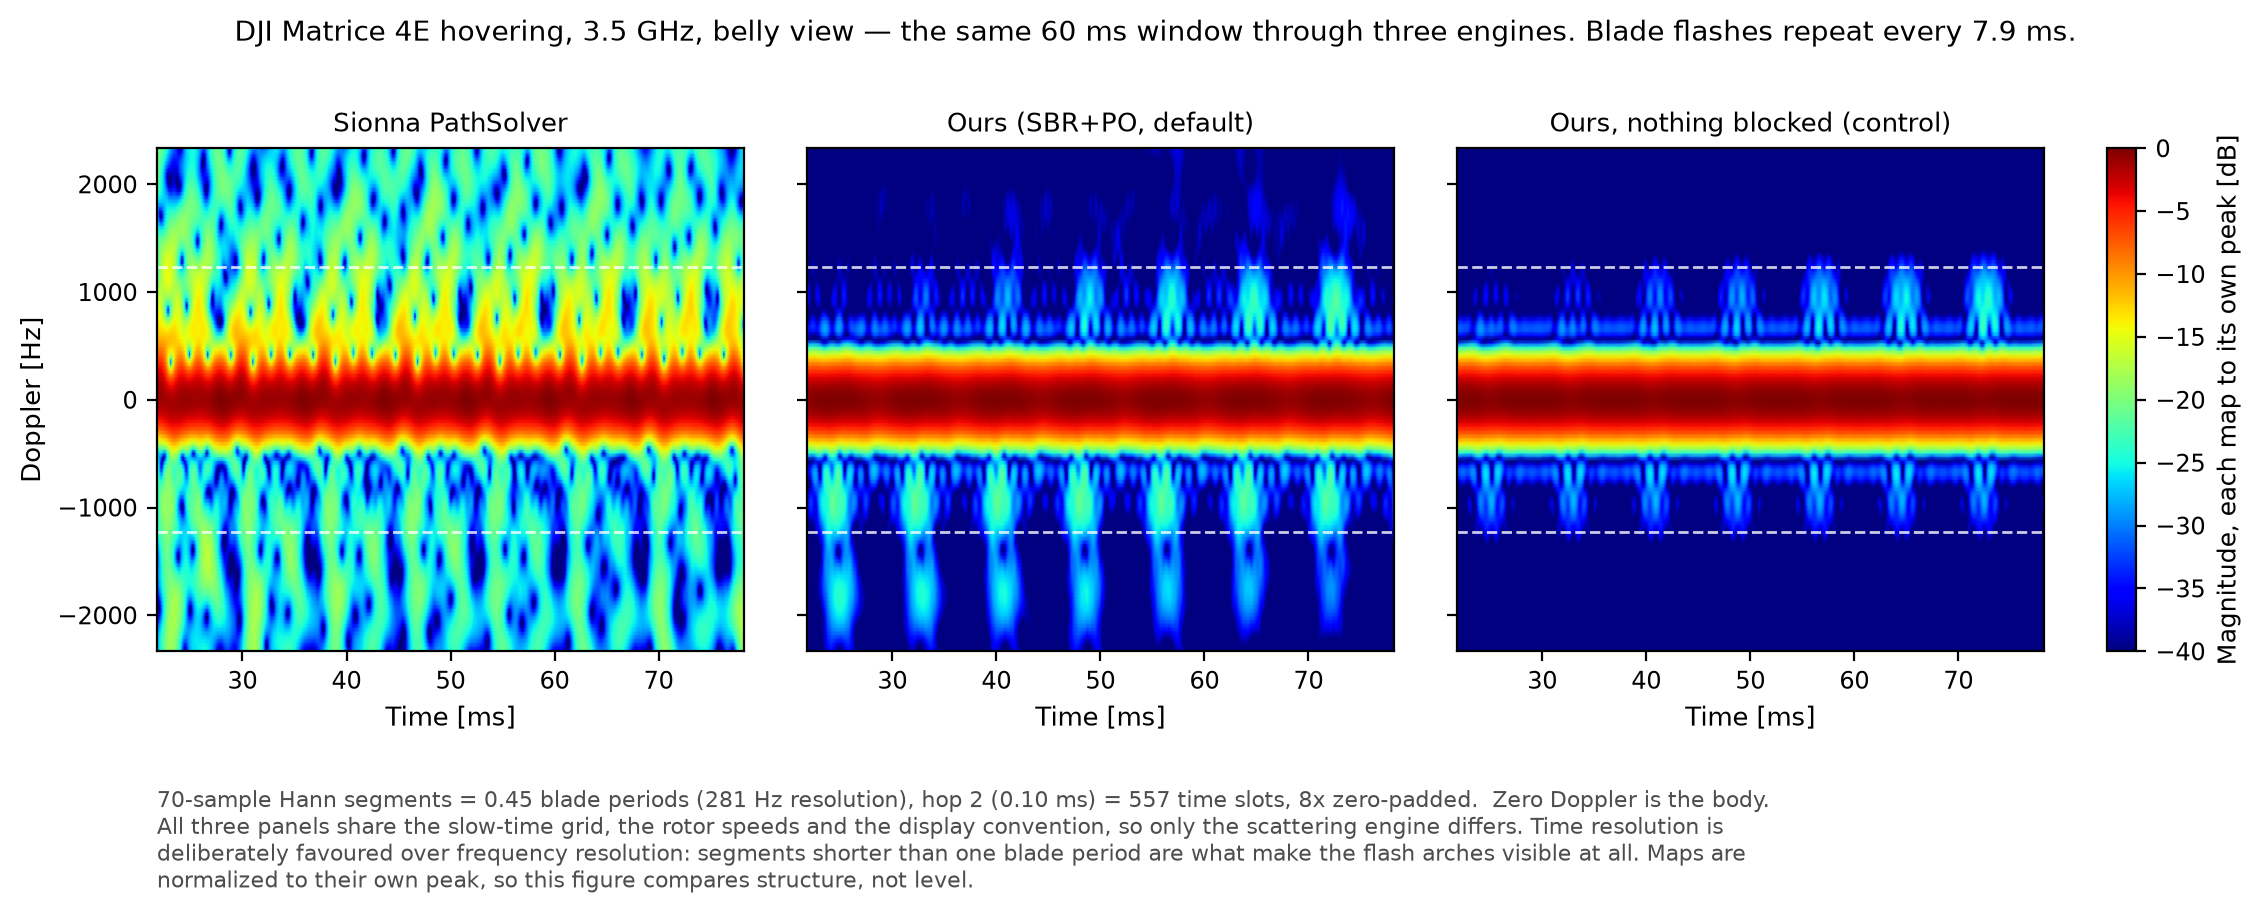

⭐ 세로 아치가 블레이드 플래시이고 **7.9 ms 마다** 반복한다(= f_flash 127 Hz). 세 엔진이 그 주기를 같이 낸다는 것이 이 그림의 첫 확인이다. 모양은 갈린다 — **우리 두 팔은 같은 자리에 같은 아치를 낸다**(대역 안 코사인 0.955). 가림을 켠 기본팔의 아치가 도플러축으로 조금 더 넓게 번지고 날개끝 선 위로 옅은 꼬리를 남기는 것이 둘의 남은 차이이며, Sionna 는 아치라기보다 얼룩에 가깝다.

⭐ **Sionna 가 왜 얼룩인가** — 프로펠러를 맞은 **정반사 경로가 이 격자에서 0 칸**이다. 자세×위상 격자 1152 칸(기체 두 대 몫)에서 정반사가 잡힌 칸이 16 칸인데, 그중 **프롭 정반사는 0 칸**이다. 남은 것은 확산 산란뿐이라 아치가 뭉개진다.

⚠ **그 격자가 무엇인지 밝힌다** — 방위 12 × 앙각 6(0~60°) × 로터 위상 8 = 기체당 576 칸, 광선 2.56 억 발이다. ⚠ **이 편의 자세(앙각 -15°)는 그 격자에 들어 있지 않다** — 프롭 원판의 법선은 위를 향하고, 인구조사는 그 위쪽만 훑었다.

⭐ **그 «0» 을 축 두 개로 시험했다**(원장 `outputs/report15_blade_flash_ladder.json`) — 한 번에 둘을 바꾸면 원인을 못 가르므로 한 축씩 열었다.

| 축 | 무엇을 바꿨나 | matrice4e | mini2 |
|---|---|---|---|
| 예산 | 광선 2.56 억 → 40.96 억(16 배) | 프롭 정반사 0 / 576 칸 | 0 / 576 칸 |
| 앙각 | 격자를 60° → 85° 까지 열기(같은 예산) | 2 / 960 칸 | 0 / 960 칸 |

⇒ **기체마다 답이 갈린다.** **matrice4e** — 앙각이었다 — 예산으로는 안 나오는데 가파른 앙각을 열면 나온다. «0» 은 격자가 프롭 법선 근처를 안 본 결과다. **mini2** — 예산도 앙각도 아니다 — 사다리 꼭대기·앙각 85° 까지 프롭 정반사가 0 칸이다. 이제서야 «스톡 RT 가 프롭 정반사를 못 낸다» 에 가까워진다.

⇒ 이 편의 자세는 프롭 원판의 법선에서 75° 떨어져 있다. 그러므로 여기서 아치가 얼룩인 것은 «이 기하에서 프롭 정반사가 없다» 와 앞뒤가 맞는다 — **모든 기하에서 없다** 는 뜻이 아니다.

⭐ **시간 분해능을 주파수 분해능보다 앞세운다.** 조각을 한 주기보다 길게 잡으면 플래시는 그 안에서 평균돼 사라지고 가로 능선만 남는다. 그래서 조각을 **한 주기보다 짧게**(0.45 주기) 잡는다 — 정본은 `src/md_mapstyle.py` 다.

⚠ **0.45 가 최적이라는 측정 근거는 없다** — 그림이 실제로 또렷해서 쓰는 값이다. 인용해도 되는 것은 정의가 하나뿐인 양뿐이다 — 조각 70 표본 · Δt 3.55 ms · Δf 281 Hz (hop 2 표본 · 제로패딩 8 배).

⚠ 세 패널은 각자 최대로 정규화했다 — 이 그림은 **구조를 비교하지 레벨을 비교하지 않는다**.

⚠⚠ **패널 사이의 레벨 차를 그대로 읽으면 안 된다.** 두 팔이 내는 양의 **단위가 다르다** — Sionna 는 1/R² 를 두 번 먹은 **수신 전력장**을 주고, 우리 커널은 표적의 **산란 진폭**[m²]을 준다. 3 m 에서 그 환산항만 −20log₁₀(4πR²) = **-41.1 dB** 다. 원장의 실측 격차 -65.5 dB 에서 환산을 빼면 남는 것은 **-24.5 dB** 이고, 그것이 «프롭 정반사 경로가 0 칸» 으로 설명해야 할 몫이다. 단위가 다른 두 수의 차를 물리량으로 인용하지 마라.


## 스톡 PathSolver 와 가림 없는 대조군이 날개끝 아래에서 겹치고 위에서 갈린다

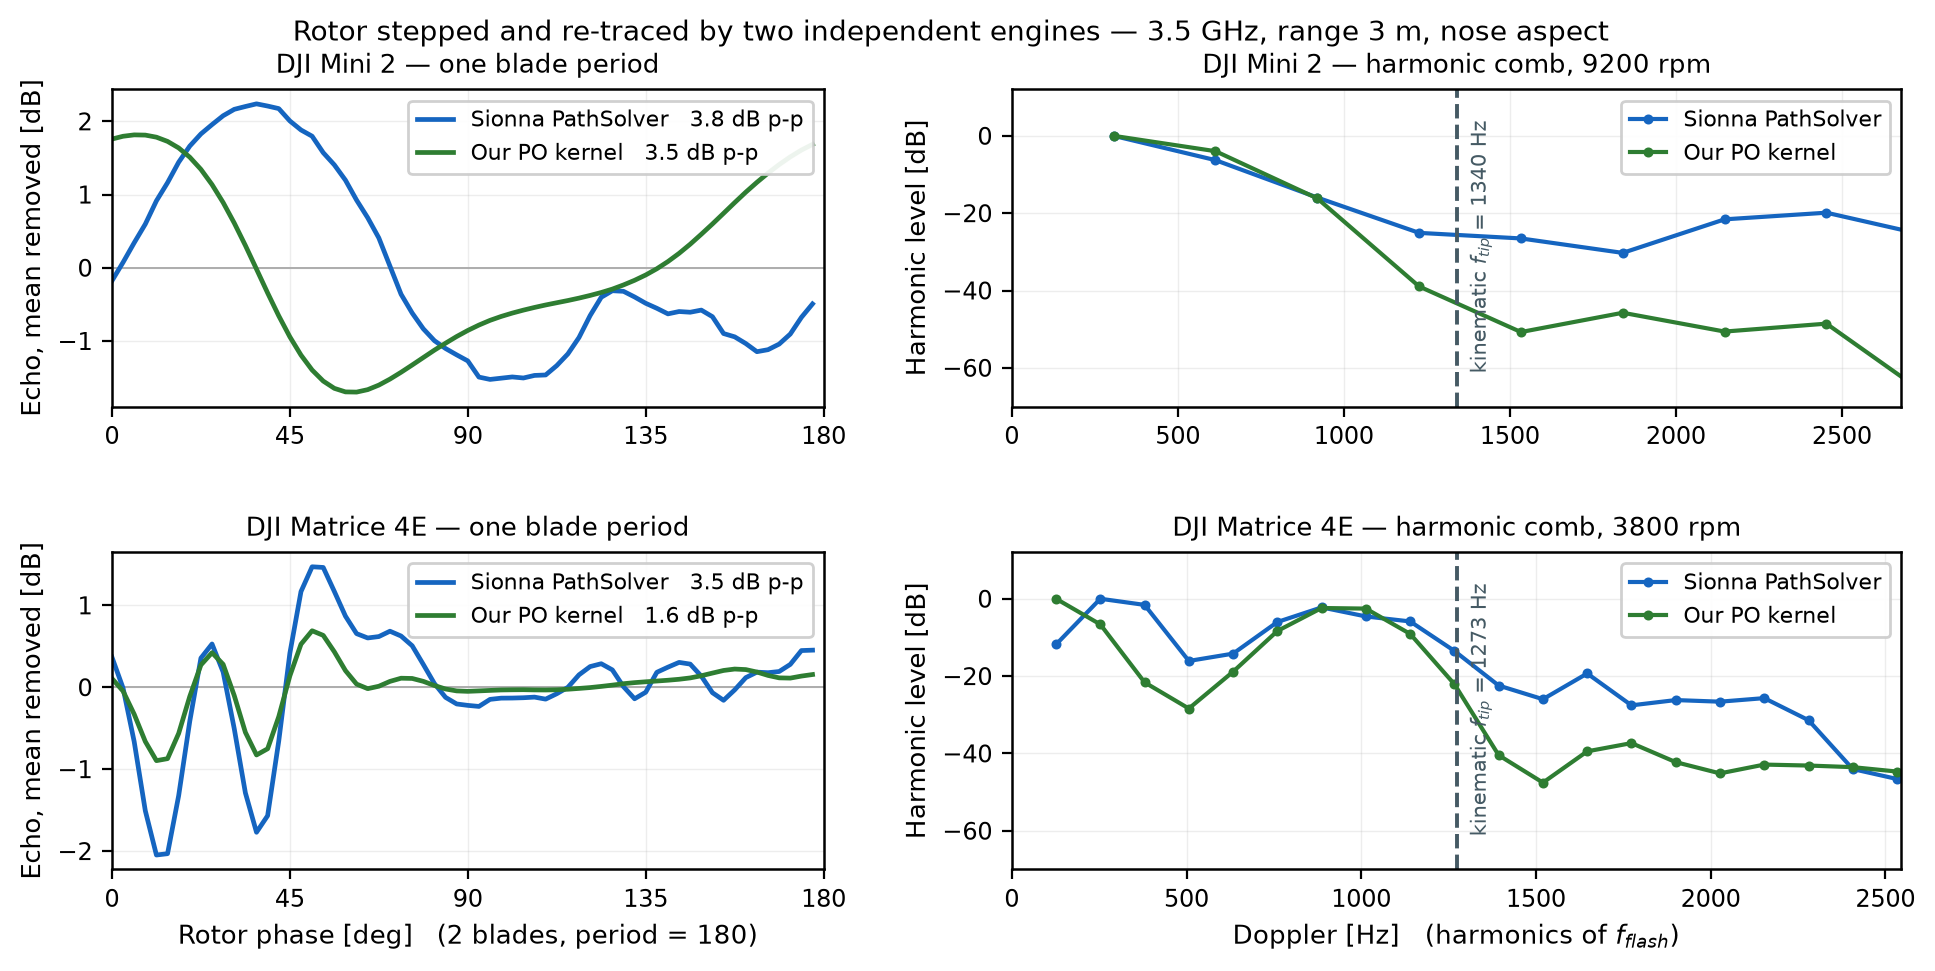

⭐ **이 그림에 선 팔은 둘이다 — Sionna PathSolver ↔ Ours, nothing blocked (control).** 원장 `outputs/report15_verdict.json` 의 최상위 팔 키가 그 둘이고(`sionna` · `po`), **Ours (SBR+PO, 기본) 은 이 원장 밖이다** — 그래서 여기서 벌어지는 폭은 «가림을 켠 우리 커널 ↔ 스톡» 이 아니라 «가림 없는 대조군 ↔ 스톡» 이다. 가림을 켠 팔로 같은 물음을 재는 자리는 위의 세 엔진 절과 그 아래 격자 절이다.

1 차원 스펙트럼으로 보면 두 팔이 **날개끝 주파수 아래에서 겹치고 위에서 갈린다**. Sionna PathSolver 꼬리가 Ours, nothing blocked (control) 대비 **14.7 dB**(matrice4e) · **27.4 dB**(mini2) 높다.

⚠ **꼬리 초과의 정의** — 날개끝 주파수 **밖**(f_tip 초과) 빈들의 평균 레벨을 두 팔에서 각각 재어 뺀 값이다(봉우리 정규화 뒤).

⚠ **이 그림만 자세도 기하도 다르다** — 자세는 08_1 의 배 쪽(el -15°) 대신 nose(el +15°)이고, 기하는 절 2 의 진짜 모노스태틱(기선 0) 대신 **준-모노스태틱 기선 0.20 m** 다. 대조군 커널도 이 원장 전용이다 — «src/microdoppler_nearfield.py — 구면파 PO, 실제 TX/RX 좌표, **가림 없음**»(`outputs/report15_verdict_po_grid.json:meta`). 원장이 다르다(`outputs/report15_verdict.json` · 2026-08-04). 무늬 세부와 절대 레벨을 위 맵들과 직접 견주면 안 된다.


## 이 편이 서 있는 자리

세 엔진이 **같은 주기**를 낸다. 모양은 **우리 두 팔끼리 거의 같고**(대역 안 코사인 0.955) 남은 갈림은 가림이 만든다. Sionna PathSolver 는 둘 모두에서 떨어져 있고(0.745 · 0.760) 그 원인은 경로 수 — 프롭 정반사가 **인구조사 격자에서** 0 칸이다.

⚠ **그 «0 칸» 이 어디까지의 0 인지 밝힌다.** 인구조사 격자는 앙각 0~60° 이고 **이 편의 자세(앙각 -15°)는 그 밖이다**. 축을 하나씩 열면 답이 기체마다 갈린다 — 앙각을 85° 까지 연 판에서 matrice4e 는 프롭 정반사가 2/960 칸으로 나오고, mini2 는 같은 판에서 0/960 칸 · 예산 사다리 꼭대기(41 억 발)에서도 0/576 칸이다(`outputs/report15_blade_flash_ladder.json` · 두 축은 따로 열었다). 그러므로 이 맺음말은 **이 기하에서의 0** 이고, 기체별 판정은 절 «블레이드 플래시를 세 엔진으로 나란히» 가 낸다.

⭐ 그리고 그 «거의 같다» 는 **광선 격자를 얼린 뒤에** 나온 자리다. 자를 자세마다 다시 놓던 판에서는 같은 두 팔이 훨씬 덜 닮았다 — **절 «광선 격자를 어디에 매나»**.

| 다음 | 무엇을 답하나 |
|---|---|
| [08_3 무늬를 정하는 것](08_3_pattern.ipynb) | 회전수·가림·산포가 무늬를 어떻게 바꾸나 |
| [08_4 무엇을 잴 수 있나](08_4_sampling.ipynb) | 이 계산을 얼마나 멀리·얼마나 자주 할 수 있나 |
| `reports/09_microdoppler-limits.ipynb` | 자세·보정·광선 예산의 단일축 분해 |


## 출처

이 편의 숫자는 아래 13 개 원장에서 난다. 표시 규약(조각 길이 · hop · 제로패딩)과 세 팔의 이름은 코드 `src/md_mapstyle.py` 가 정본이다.

| 원장 | 키 | 이 편의 어디에 |
|---|---|---|
| `outputs/report07_three_engines.json` | `_meta` · `engines.sbr.grid_ref` · `levels_db` · `verdict.cosine_in_ftip` | 슬로타임 격자 · 얼린 판 · 두 팔의 레벨 차 · 세 팔 코사인 |
| `outputs/report07_depth_robust.json` | `engines.*` · `sionna_by_range` | 깊이 표(p-p · p5~p95)와 거리별 요동 |
| `outputs/outofband_power.json` | `three_engines` · `three_engines_ranking` | 대역밖 표와 그 대소 판정 |
| `outputs/report07_three_engine_ranges.json` | `_meta.grid_note_ko` · `ranges.R{3,8,15}` | 거리 표 — Sionna 열만 |
| `outputs/probe_8m_anomaly.json` | `runs_512pose` · `prior_probe_reanalysis` | 시드 사다리 · √spp 기울기 |
| `outputs/sbr_grid_convergence.json` | `rows` · `in_band_fidelity.rows` | 격자 사다리 — 간격 · 광선 수 · 코사인 |
| `outputs/verify_frozen_grid.json` | `gate1_bit_identity` · `gate2_frozen_grid_invariant` · `gate3_coverage` · `field_level` | 자 흔들림 실측(검증판)과 «대가» 표 |
| `outputs/freeze_before_after.json` | `ledgers` · `summary` · `additivity` · `off_switch_gate` | 얼리기 전후 27 열과 가산성 검사 |
| `outputs/report15_verdict.json` | `sionna` · `po` · `tail_excess` | 절 «…겹치고 위에서 갈린다» 의 두 팔과 꼬리 초과 |
| `outputs/report15_verdict_po_grid.json` | `meta.baseline_m` · `meta.engine` | 그 절의 기하(기선)와 대조군 커널 |
| `outputs/report15b_microdoppler.json` | `cells[matrice4e/belly].findings` | 가림만 떼어낸 축(F ↔ G)의 실측 |
| `outputs/report15_blade_flash_ladder.json` | `_meta` · `budget_axis` · `elevation_axis` · `verdict` | 정반사 «0 칸» 의 예산·앙각 시험 |
| `outputs/report00_microdoppler.json` | `specular_census` · `rows[matrice4e].farfield_m` | 정반사 인구조사 총계 · 원거리장 경계 |

⚠ 그림 `report07_f2` 는 위 목록의 `report15_verdict.json` 계열에서 나고, 나머지 그림(`report07_f12` · `report07_f8`)은 세 엔진 원장에서 난다 — 두 계열은 자세도 기하도 달라 절대 레벨을 섞어 읽으면 어긋난다.
